Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Motor_Symptoms

Results:
Accuracy : 0.3302430984754841
Precision: 0.32948671050578393
Recall   : 0.3302430984754841
F1-score : 0.328737685120437
              precision    recall  f1-score   support

        Mild       0.32      0.28      0.30      3201
    Moderate       0.34      0.39      0.36      3285
      Severe       0.33      0.32      0.33      3222

    accuracy                           0.33      9708
   macro avg       0.33      0.33      0.33      9708
weighted avg       0.33      0.33      0.33      9708



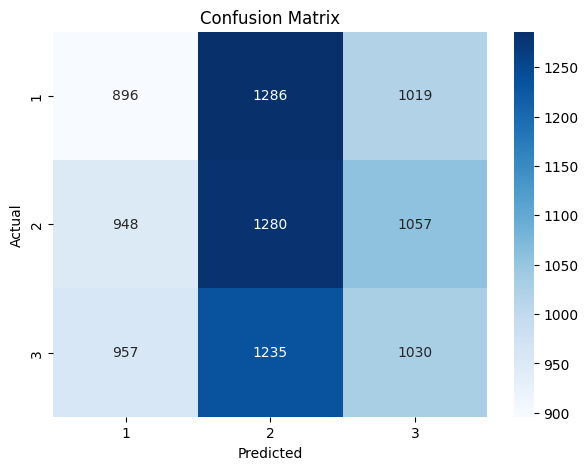

In [ ]:

# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Mount Drive & Load Dataset

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# Prepare Target

target_col = 'Motor_Symptoms'
y = df[target_col].values

# Drop target and leakage columns
leakage_cols = [

    'Patient_ID',
    target_col   # drop target from features
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)


# Train Logistic Regression

print("\n========================================")
print(f"Training Logistic Regression for: {target_col}")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print(classification_report(
    y_test,
    model.predict(X_test),
    target_names=['Mild', 'Moderate', 'Severe'],
    zero_division=0
))

# Confusion Matrix & Visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Mounted at /content/drive
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Disease_Stage

Results:
Accuracy : 0.2517511330861145
Precision: 0.2517073511689775
Recall   : 0.2517511330861145
F1-score : 0.244959834264074
                 precision    recall  f1-score   support

Pre-Symptomatic       0.25      0.34      0.29      2401
          Early       0.27      0.19      0.22      2457
         Middle       0.25      0.32      0.29      2456
           Late       0.24      0.15      0.18      2394

       accuracy                           0.25      9708
      macro avg       0.25      0.25      0.24      9708
   weighted avg       0.25      0.25      0.24      9708



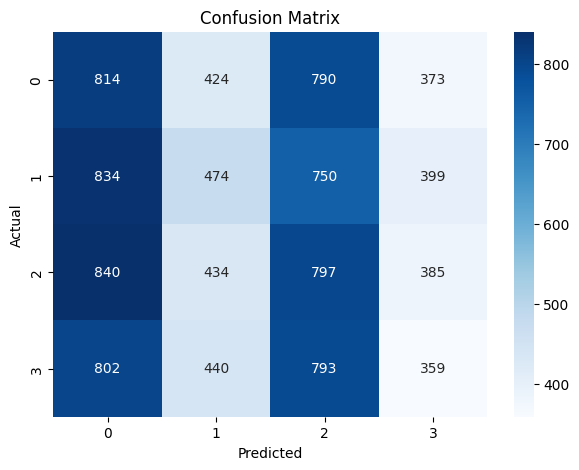

In [ ]:
# Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Mount Drive & Load Dataset

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)

# Prepare Target

target_col = 'Disease_Stage'
y = df[target_col].values

# Prepare Features

leakage_cols = [

    'Patient_ID',

    target_col   # drop target
]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label encode categorical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)

# Train Logistic Regression

print("\n========================================")
print(f"Training Logistic Regression for: {target_col}")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print(classification_report(
    y_test,
    model.predict(X_test),
    target_names=['Pre-Symptomatic', 'Early', 'Middle', 'Late'],
    zero_division=0
))
# Confusion Matrix & Visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: (48536, 28)

Training Logistic Regression for: Category

Results:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:

                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      2446
Trans-acting Modifier       1.00      1.00      1.00      4856
  Cis-acting Modifier       1.00      1.00      1.00      2406

             accuracy                           1.00      9708
            macro avg       1.00      1.00      1.00      9708
         weighted avg       1.00      1.00      1.00      9708



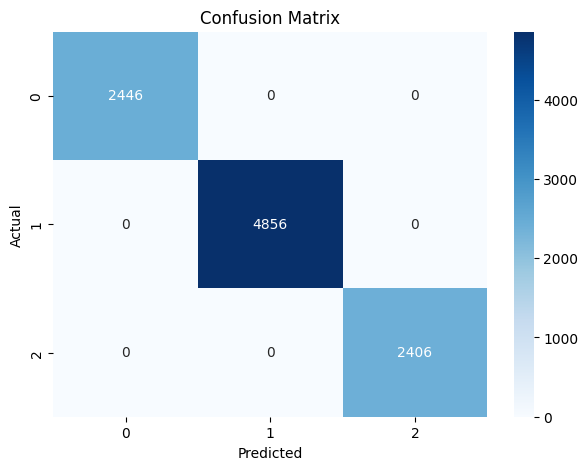

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Mount Drive & Load Dataset

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Dataset loaded successfully:", df.shape)


#Convert one-hot target → single label

def onehot_to_label(row):
    if row['Category_Primary Cause'] == 1:
        return 0   # Primary Cause
    elif row['Category_Trans-acting Modifier'] == 1:
        return 1   # Trans-acting Modifier
    else:
        return 2   # Cis-acting Modifier

df['Category'] = df.apply(onehot_to_label, axis=1)

y = df['Category'].values

# Prepare Features
leakage_cols = [

    'Patient_ID',                  # ID column
    'Random_Protein_Sequence',     # synthetic / deterministic
    'Random_Gene_Sequence',        # synthetic / deterministic

]

X = df.drop(columns=leakage_cols, errors='ignore')

# Label Encode categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.values

# Train/Test/Validation Split: 20% train, 10% val, 70% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.3333, random_state=42, stratify=y_trainval
)


#  Train Logistic Regression

print("\n========================================")
print("Training Logistic Regression for: Category")
print("========================================")

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("\nResults:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Primary Cause',
        'Trans-acting Modifier',
        'Cis-acting Modifier'
    ]
))
# Confusion Matrix & Visualization

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Columns to check
category_cols = ['Category', 'Category_Primary Cause', 'Category_Trans-acting Modifier']

print("=== Category Columns Summary ===\n")

for col in category_cols:
    print(f"Column: {col}")

    # Unique values
    unique_vals = df[col].unique()
    print(f"  Unique values       : {unique_vals}")

    # Value counts
    counts = df[col].value_counts()
    print(f"  Value counts:\n{counts}")

    # Check for missing values
    missing = df[col].isnull().sum()
    print(f"  Missing values      : {missing}")

    # Optional: check for rare categories (less than 1% of data)
    rare_threshold = 0.01 * len(df)
    rare_vals = counts[counts < rare_threshold]
    if not rare_vals.empty:
        print(f"  Rare categories (<1% of data):\n{rare_vals}")
    else:
        print(f"  No rare categories (<1%)")

    print("-" * 50)


=== Category Columns Summary ===

Column: Category
  Unique values       : [0 1 2]
  Value counts:
Category
1    24279
0    12229
2    12028
Name: count, dtype: int64
  Missing values      : 0
  No rare categories (<1%)
--------------------------------------------------
Column: Category_Primary Cause
  Unique values       : [1 0]
  Value counts:
Category_Primary Cause
0    36307
1    12229
Name: count, dtype: int64
  Missing values      : 0
  No rare categories (<1%)
--------------------------------------------------
Column: Category_Trans-acting Modifier
  Unique values       : [0 1]
  Value counts:
Category_Trans-acting Modifier
1    24279
0    24257
Name: count, dtype: int64
  Missing values      : 0
  No rare categories (<1%)
--------------------------------------------------


In [ ]:
# Columns to check
category_cols = ['Category', 'Category_Primary Cause', 'Category_Trans-acting Modifier']

# Expected values
expected_values = {
    'Category': [0, 1, 2],
    'Category_Primary Cause': [0, 1],
    'Category_Trans-acting Modifier': [0, 1]
}

print("=== Category Columns Outlier Check ===\n")

for col in category_cols:
    unexpected = df[~df[col].isin(expected_values[col])]

    if unexpected.empty:
        print(f"{col}: No outliers ✅")
    else:
        print(f"{col}: Outliers found ❌")
        print(unexpected[col].unique())


=== Category Columns Outlier Check ===

Category: No outliers ✅
Category_Primary Cause: No outliers ✅
Category_Trans-acting Modifier: No outliers ✅
